<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/14_speech_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 14 — Speech Augmentation

## What This Notebook Covers
Speech augmentation operates in both the **time domain** (raw waveform)
and the **frequency domain** (spectrograms). The key insight is that
humans recognize speech robustly across a wide range of conditions:
different speakers, background noise, room acoustics, recording quality.
Our models should too.

**Techniques covered:**
- Time domain: time stretch, pitch shift, gain, polarity inversion
- Noise: additive white noise, background noise injection
- Room simulation: room impulse response convolution
- Spectrogram: SpecAugment (time masking + frequency masking)
- Spectrogram: time warping on mel spectrograms
- `audiomentations` library pipeline
- Feature extraction: Mel spectrogram, MFCC
- Speech classifier (CNN on mel spectrograms)
- A/B test: no augmentation vs full pipeline

**Dataset:** SpeechCommands (Google) — keyword spotting


In [1]:
!pip install audiomentations torchaudio --quiet

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import audiomentations as AM
from scipy.signal import fftconvolve
from scipy.io import wavfile
import random
import os

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torchaudio   :', torchaudio.__version__)
print('audiomentations imported')
print('Device       :', device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 10.0 MB/s eta 0:00:00
torchaudio   : 2.10.0+cu128
audiomentations imported
Device       : cuda


## 1. Load SpeechCommands Dataset

Google SpeechCommands contains 1-second audio clips of spoken keywords.
We use a 10-class subset: yes, no, up, down, left, right, on, off, stop, go.
Each clip is 16kHz mono — 16,000 samples per second.


In [3]:
import os

# Create the data directory if it doesn't exist
if not os.path.exists('./data'):
    os.makedirs('./data')

# Download SpeechCommands v2 (about 2.3GB)
print('Downloading SpeechCommands dataset (~2.3GB)...')
train_dataset_raw = torchaudio.datasets.SPEECHCOMMANDS(
    root='./data',
    url='speech_commands_v0.02',
    folder_in_archive='SpeechCommands',
    download=True,
    subset='training'
)
test_dataset_raw = torchaudio.datasets.SPEECHCOMMANDS(
    root='./data',
    url='speech_commands_v0.02',
    folder_in_archive='SpeechCommands',
    download=True,
    subset='testing'
)

# 10-class subset
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
SAMPLE_RATE = 16000
CLIP_LEN    = 16000   # 1 second


def filter_dataset(dataset, labels):
    """Keep only samples with labels in the target set."""
    samples = []
    for waveform, sr, label, *_ in dataset:
        if label in labels:
            # Pad or trim to exactly CLIP_LEN samples
            wav = waveform[0].numpy()   # (samples,) float32
            if len(wav) < CLIP_LEN:
                wav = np.pad(wav, (0, CLIP_LEN - len(wav)))
            else:
                wav = wav[:CLIP_LEN]
            samples.append((wav.astype(np.float32), LABEL2IDX[label]))
    return samples


print('Filtering to 10-class subset...')
train_samples = filter_dataset(train_dataset_raw, LABELS)
test_samples  = filter_dataset(test_dataset_raw,  LABELS)

train_wavs  = np.array([s[0] for s in train_samples])
train_labels = np.array([s[1] for s in train_samples])
test_wavs   = np.array([s[0] for s in test_samples])
test_labels  = np.array([s[1] for s in test_samples])

print(f'Train: {train_wavs.shape}  ({len(train_wavs)} clips)')
print(f'Test : {test_wavs.shape}')
print(f'Waveform range: [{train_wavs.min():.3f}, {train_wavs.max():.3f}]')

from collections import Counter
label_counts = Counter(train_labels.tolist())
print('\nClass distribution (train):')
for idx, count in sorted(label_counts.items()):
    print(f'  {LABELS[idx]:8s}: {count}')

100%|██████████| 2.26G/2.26G [00:59<00:00, 40.5MB/s]


Filtering to 10-class subset...
Train: (30769, 16000)  (30769 clips)
Test : (4074, 16000)
Waveform range: [-1.000, 1.000]

Class distribution (train):
  yes     : 3228
  no      : 3130
  up      : 2948
  down    : 3134
  left    : 3037
  right   : 3019
  on      : 3086
  off     : 2970
  stop    : 3111
  go      : 3106


## 2. Visualisation Helper — Waveform + Spectrogram


Demo sample: "down"


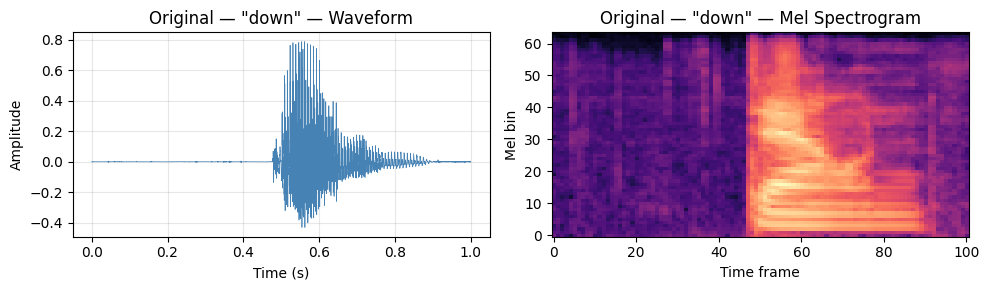

In [4]:
def plot_audio(waveform, sr=SAMPLE_RATE, title='', ax_wave=None, ax_spec=None):
    """Plot waveform and mel spectrogram side by side."""
    if ax_wave is None:
        fig, (ax_wave, ax_spec) = plt.subplots(1, 2, figsize=(10, 3))

    t = np.arange(len(waveform)) / sr
    ax_wave.plot(t, waveform, color='steelblue', linewidth=0.5)
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_title(f'{title} — Waveform')
    ax_wave.grid(True, alpha=0.3)

    # Mel spectrogram
    wav_t  = torch.tensor(waveform).unsqueeze(0)
    mel_t  = T.MelSpectrogram(sample_rate=sr, n_mels=64, n_fft=512,
                               hop_length=160)(wav_t)
    mel_db = T.AmplitudeToDB()(mel_t).squeeze().numpy()

    ax_spec.imshow(mel_db, aspect='auto', origin='lower',
                   cmap='magma', interpolation='nearest')
    ax_spec.set_xlabel('Time frame')
    ax_spec.set_ylabel('Mel bin')
    ax_spec.set_title(f'{title} — Mel Spectrogram')


def show_aug_audio(original, augmented, label='word', aug_name=''):
    """Show original and augmented waveform + spectrogram."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 5))
    plot_audio(original,  title=f'Original ({label})',    ax_wave=axes[0,0], ax_spec=axes[0,1])
    plot_audio(augmented, title=f'{aug_name} ({label})', ax_wave=axes[1,0], ax_spec=axes[1,1])
    plt.tight_layout()
    plt.show()


# Pick a sample to use throughout
SAMPLE_WAV   = train_wavs[0].copy()
SAMPLE_LABEL = LABELS[train_labels[0]]
print(f'Demo sample: "{SAMPLE_LABEL}"')
plot_audio(SAMPLE_WAV, title=f'Original — "{SAMPLE_LABEL}"')
plt.tight_layout()
plt.show()

## 3. Time Domain Augmentations

These operate directly on the raw waveform samples.


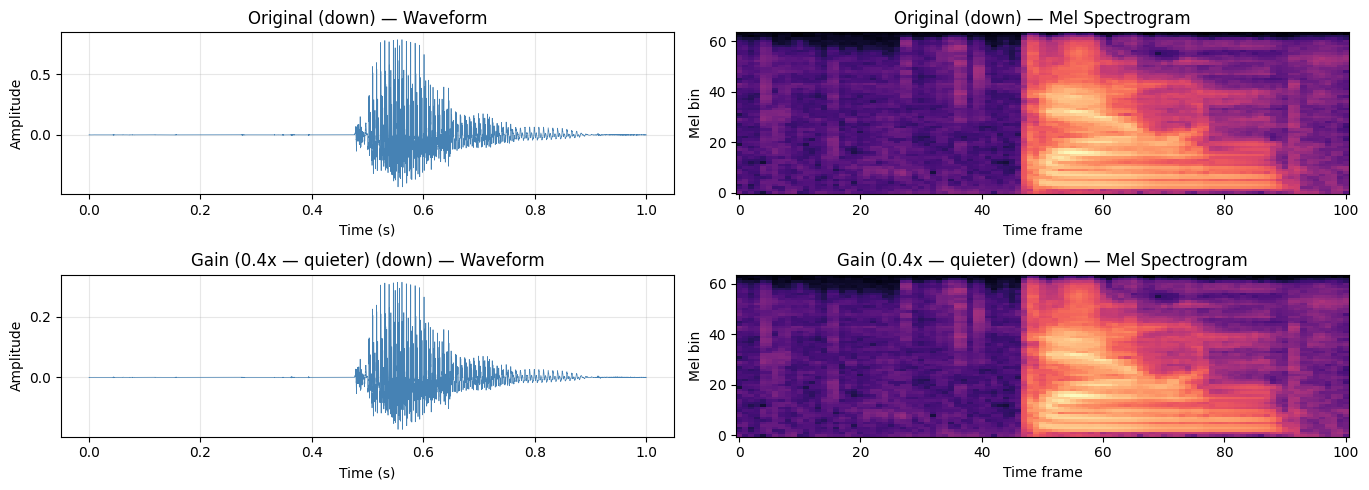

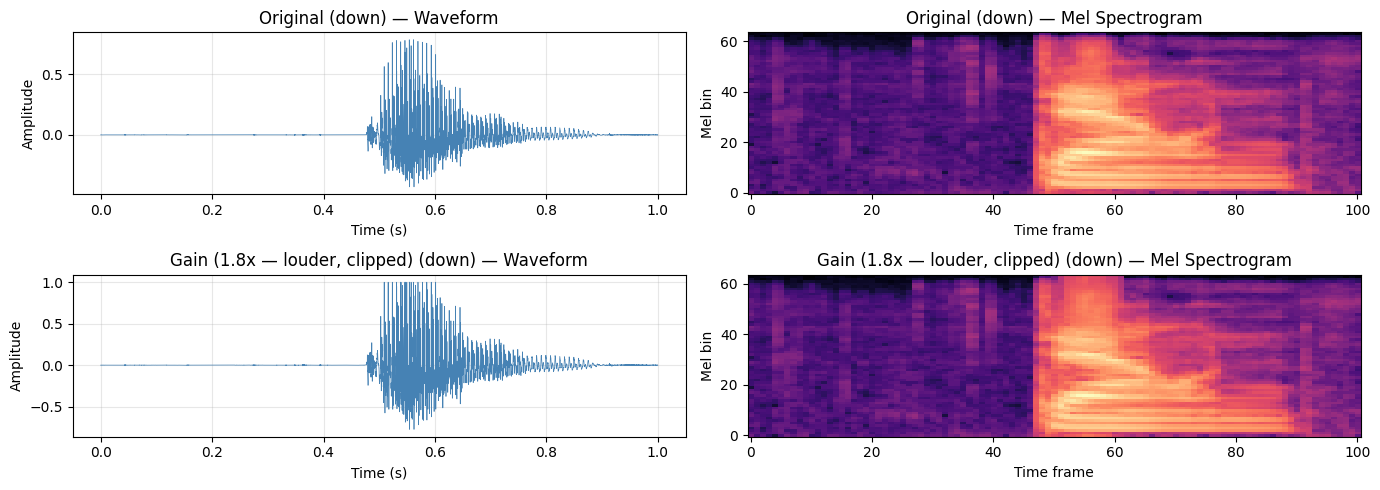

In [5]:
# --- Gain: multiply waveform by a random scalar ---
# Simulates different recording volumes / microphone sensitivities
def gain(wav, min_gain=0.5, max_gain=1.5):
    g = np.random.uniform(min_gain, max_gain)
    return np.clip(wav * g, -1.0, 1.0).astype(np.float32)

show_aug_audio(SAMPLE_WAV, gain(SAMPLE_WAV, 0.4, 0.4),
               label=SAMPLE_LABEL, aug_name='Gain (0.4x — quieter)')

show_aug_audio(SAMPLE_WAV, gain(SAMPLE_WAV, 1.8, 1.8),
               label=SAMPLE_LABEL, aug_name='Gain (1.8x — louder, clipped)')

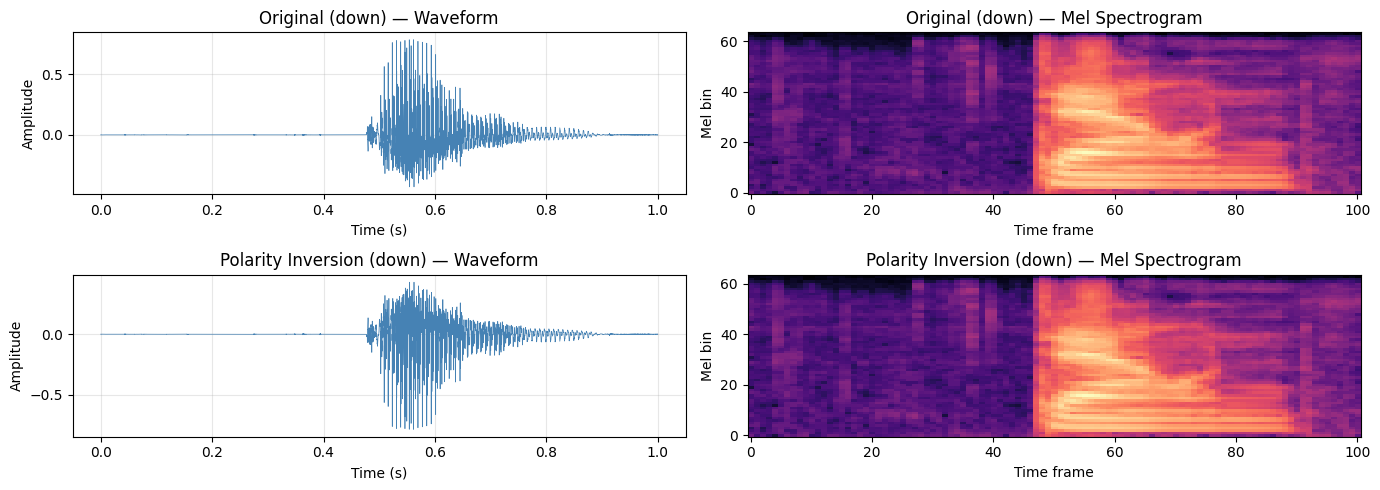

In [6]:
# --- Polarity Inversion: flip the waveform vertically ---
# Sound content is identical — human hearing is phase-insensitive
# Forces model to be sign-invariant
def polarity_inversion(wav):
    return -wav

show_aug_audio(SAMPLE_WAV, polarity_inversion(SAMPLE_WAV),
               label=SAMPLE_LABEL, aug_name='Polarity Inversion')

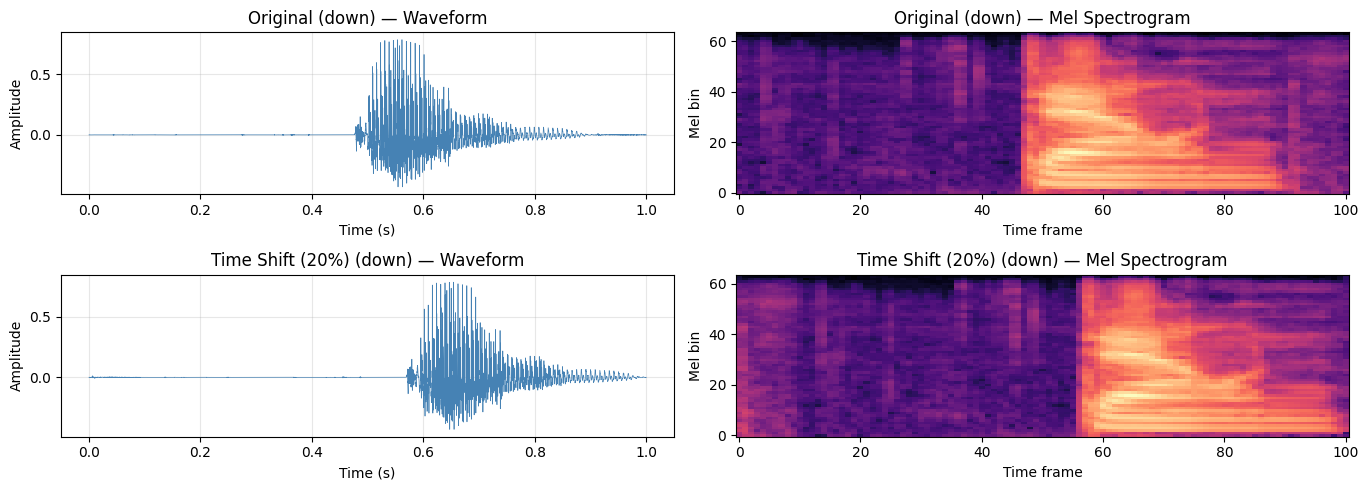

In [7]:
# --- Time Shift: shift waveform left or right, wrapping around ---
# Simulates the keyword starting at different points in the recording
def time_shift(wav, max_shift_frac=0.2):
    shift = int(np.random.uniform(-max_shift_frac, max_shift_frac) * len(wav))
    return np.roll(wav, shift).astype(np.float32)

show_aug_audio(SAMPLE_WAV, time_shift(SAMPLE_WAV, max_shift_frac=0.2),
               label=SAMPLE_LABEL, aug_name='Time Shift (20%)')

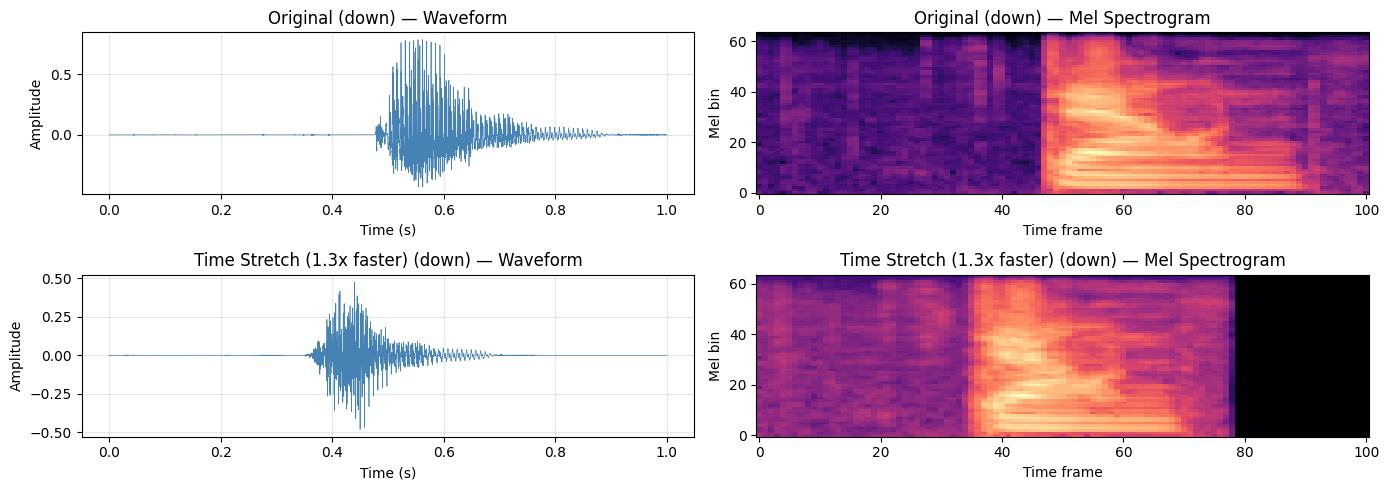

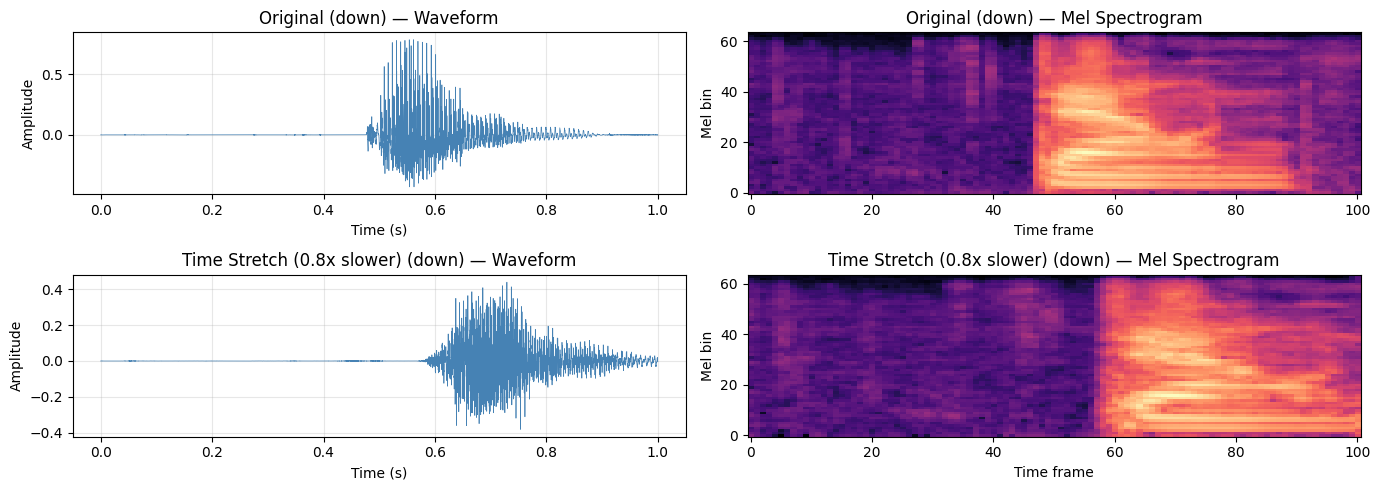

In [8]:
# --- Time Stretch: speed up or slow down without changing pitch ---
# Uses phase vocoder algorithm via torchaudio
def time_stretch(wav, rate=1.2):
    """
    Stretch time by 'rate' factor without changing pitch.
    rate > 1: faster (shorter clip, then padded/trimmed to original length)
    rate < 1: slower (longer clip, then trimmed)
    """
    wav_t   = torch.tensor(wav).unsqueeze(0)   # (1, samples)
    stretch = T.TimeStretch(n_freq=257, fixed_rate=rate)
    # TimeStretch operates on complex spectrogram
    spec    = torch.stft(wav_t[0], n_fft=512, hop_length=160, window=torch.hann_window(512),
                          return_complex=True).unsqueeze(0)
    stretched_spec = stretch(spec)
    wav_out = torch.istft(stretched_spec[0], n_fft=512, hop_length=160,
                           window=torch.hann_window(512)).numpy()

    # Pad or trim to original length
    if len(wav_out) < len(wav):
        wav_out = np.pad(wav_out, (0, len(wav) - len(wav_out)))
    else:
        wav_out = wav_out[:len(wav)]
    return wav_out.astype(np.float32)

show_aug_audio(SAMPLE_WAV, time_stretch(SAMPLE_WAV, rate=1.3),
               label=SAMPLE_LABEL, aug_name='Time Stretch (1.3x faster)')

show_aug_audio(SAMPLE_WAV, time_stretch(SAMPLE_WAV, rate=0.8),
               label=SAMPLE_LABEL, aug_name='Time Stretch (0.8x slower)')

## 4. Noise Augmentation

Background noise makes models robust to real-world recording conditions.
Signal-to-noise ratio (SNR) controls how loud the noise is relative to speech.
Higher SNR = cleaner speech. Lower SNR = noisier.


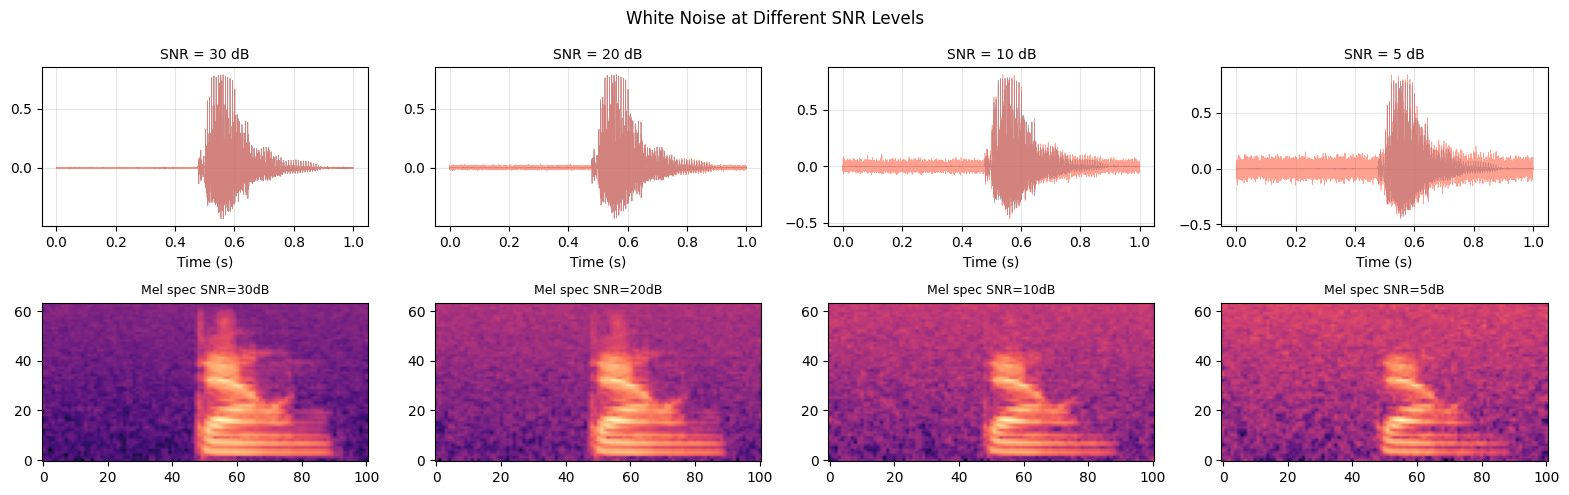

In [9]:
def add_white_noise(wav, snr_db=20):
    """
    Add white Gaussian noise at a specified SNR.
    SNR in dB: higher = cleaner. 20dB is light noise, 5dB is heavy.

    noise_power = signal_power / (10 ^ (snr_db / 10))
    """
    signal_power = np.mean(wav ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.randn(len(wav)) * np.sqrt(noise_power)
    return np.clip(wav + noise, -1.0, 1.0).astype(np.float32)


# Show effect of different SNR levels
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
snr_values = [30, 20, 10, 5]

for i, snr in enumerate(snr_values):
    noisy = add_white_noise(SAMPLE_WAV, snr_db=snr)
    t     = np.arange(len(SAMPLE_WAV)) / SAMPLE_RATE

    axes[0, i].plot(t, SAMPLE_WAV, color='steelblue', alpha=0.6, linewidth=0.5)
    axes[0, i].plot(t, noisy, color='tomato', alpha=0.6, linewidth=0.5)
    axes[0, i].set_title(f'SNR = {snr} dB', fontsize=10)
    axes[0, i].set_xlabel('Time (s)')
    axes[0, i].grid(True, alpha=0.3)

    # Mel spectrogram
    mel = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=512, hop_length=160)
    mel_db = T.AmplitudeToDB()(mel(torch.tensor(noisy).unsqueeze(0))).squeeze().numpy()
    axes[1, i].imshow(mel_db, aspect='auto', origin='lower', cmap='magma')
    axes[1, i].set_title(f'Mel spec SNR={snr}dB', fontsize=9)

plt.suptitle('White Noise at Different SNR Levels', fontsize=12)
plt.tight_layout()
plt.show()

## 5. audiomentations Pipeline

`audiomentations` is the audio equivalent of albumentations.
It provides a wide range of augmentations with a clean Compose API.


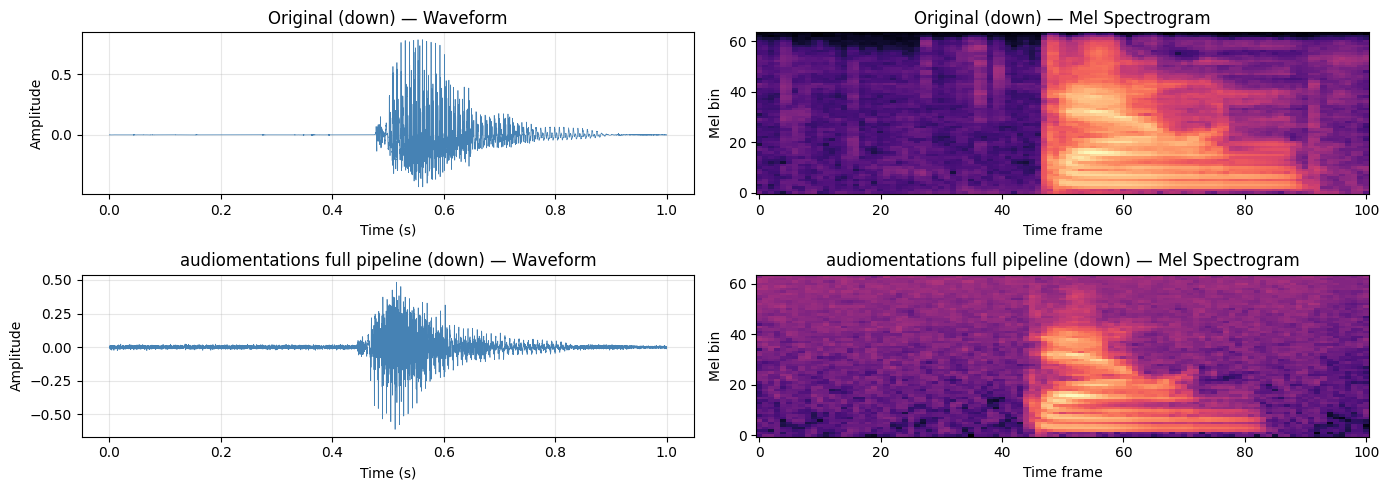

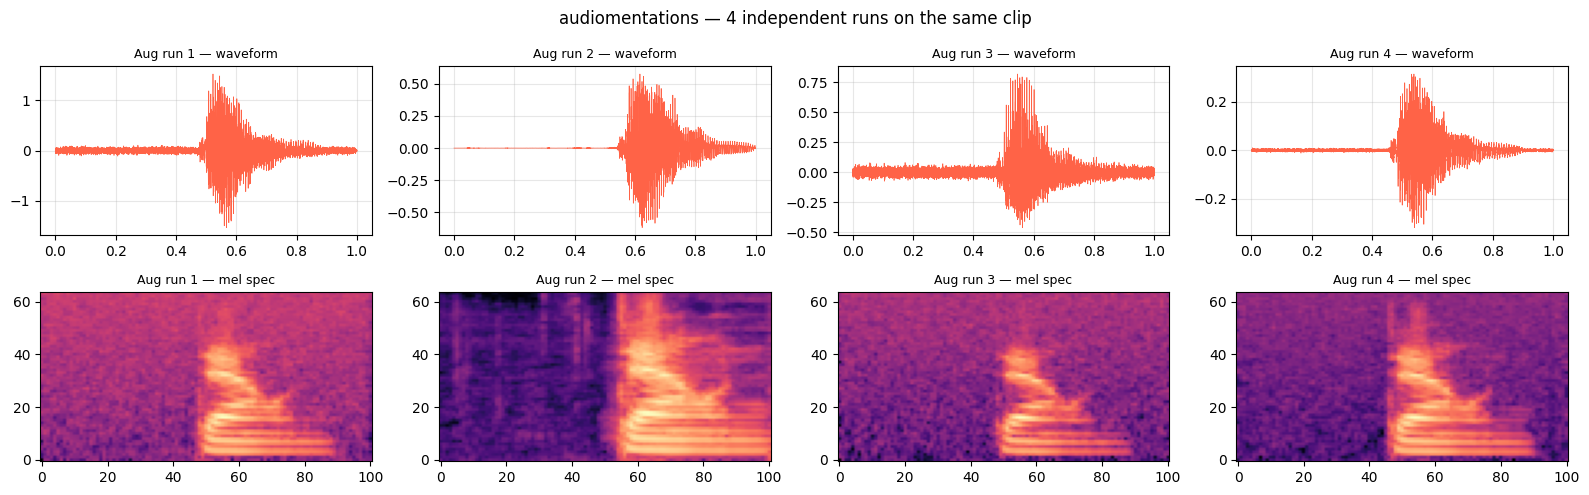

In [17]:
# Define the augmentation pipeline
# Each transform has a probability p of being applied
train_aug = AM.Compose([
    AM.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.02, p=0.5),
    AM.TimeStretch(min_rate=0.85, max_rate=1.15, p=0.4),
    AM.PitchShift(min_semitones=-3, max_semitones=3, p=0.4),
    AM.Shift(min_shift=-0.2, max_shift=0.2, p=0.5),
    AM.Gain(p=0.5),
    AM.PolarityInversion(p=0.3),
    AM.AddGaussianSNR(p=0.3),
])

# Apply and visualise
augmented_wav = train_aug(SAMPLE_WAV, sample_rate=SAMPLE_RATE)
show_aug_audio(SAMPLE_WAV, augmented_wav,
               label=SAMPLE_LABEL,
               aug_name='audiomentations full pipeline')

# Show 4 independent runs
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for i in range(4):
    aug = train_aug(SAMPLE_WAV.copy(), sample_rate=SAMPLE_RATE)
    t   = np.arange(CLIP_LEN) / SAMPLE_RATE

    axes[0, i].plot(t, aug, color='tomato', linewidth=0.5)
    axes[0, i].set_title(f'Aug run {i+1} — waveform', fontsize=9)
    axes[0, i].grid(True, alpha=0.3)

    mel_db = T.AmplitudeToDB()(
        T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=512, hop_length=160)(
            torch.tensor(aug).unsqueeze(0)
        )
    ).squeeze().numpy()
    axes[1, i].imshow(mel_db, aspect='auto', origin='lower', cmap='magma')
    axes[1, i].set_title(f'Aug run {i+1} — mel spec', fontsize=9)

plt.suptitle('audiomentations — 4 independent runs on the same clip', fontsize=12)
plt.tight_layout()
plt.show()

## 6. SpecAugment — Frequency and Time Masking

SpecAugment (Park et al. 2019) is the most widely used spectrogram
augmentation technique. It was shown to significantly improve ASR
(automatic speech recognition) accuracy.

Three operations:
1. **Time warping**: non-linear warp of the time axis
2. **Frequency masking**: zero out F consecutive mel bins
3. **Time masking**: zero out T consecutive time frames

The masking operations are the most impactful.
They force the model to not rely on specific frequencies or time frames.


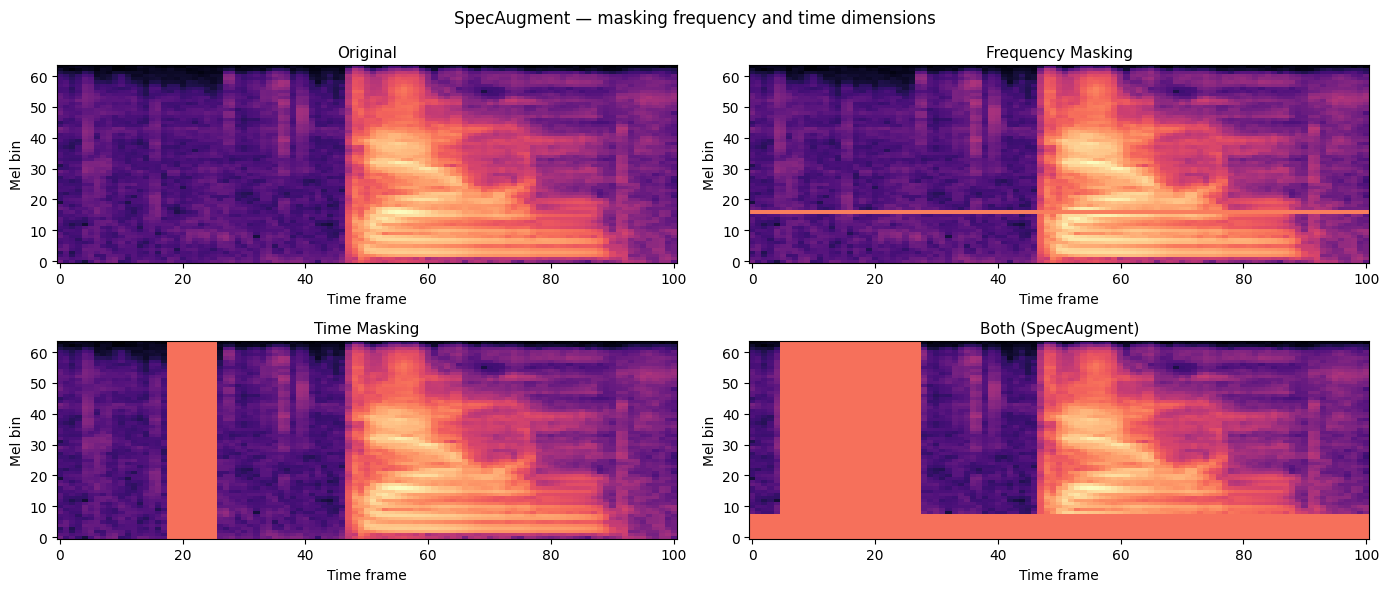

Frequency masking: zeros out horizontal bands (mel bins)
Time masking     : zeros out vertical bands (time frames)
Combined         : model cannot rely on any specific frequency or time region


In [18]:
def compute_mel_spectrogram(wav, sr=SAMPLE_RATE, n_mels=64, n_fft=512, hop_length=160):
    """Convert waveform to log-mel spectrogram tensor (1, n_mels, time_frames)."""
    wav_t  = torch.tensor(wav).unsqueeze(0)
    mel    = T.MelSpectrogram(sample_rate=sr, n_mels=n_mels,
                               n_fft=n_fft, hop_length=hop_length)(wav_t)
    mel_db = T.AmplitudeToDB()(mel)
    return mel_db   # (1, n_mels, time_frames)


# torchaudio has built-in SpecAugment transforms
freq_masking = T.FrequencyMasking(freq_mask_param=15)   # mask up to 15 mel bins
time_masking = T.TimeMasking(time_mask_param=25)         # mask up to 25 time frames

mel_original = compute_mel_spectrogram(SAMPLE_WAV)

# Apply SpecAugment
mel_freq_masked = freq_masking(mel_original.clone())
mel_time_masked = time_masking(mel_original.clone())
# Both together
mel_both        = time_masking(freq_masking(mel_original.clone()))

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
titles = ['Original', 'Frequency Masking', 'Time Masking', 'Both (SpecAugment)']
specs  = [mel_original, mel_freq_masked, mel_time_masked, mel_both]

for ax, spec, title in zip(axes.flatten(), specs, titles):
    ax.imshow(spec.squeeze().numpy(), aspect='auto', origin='lower',
              cmap='magma', interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Time frame')
    ax.set_ylabel('Mel bin')

plt.suptitle('SpecAugment — masking frequency and time dimensions', fontsize=12)
plt.tight_layout()
plt.show()

print('Frequency masking: zeros out horizontal bands (mel bins)')
print('Time masking     : zeros out vertical bands (time frames)')
print('Combined         : model cannot rely on any specific frequency or time region')

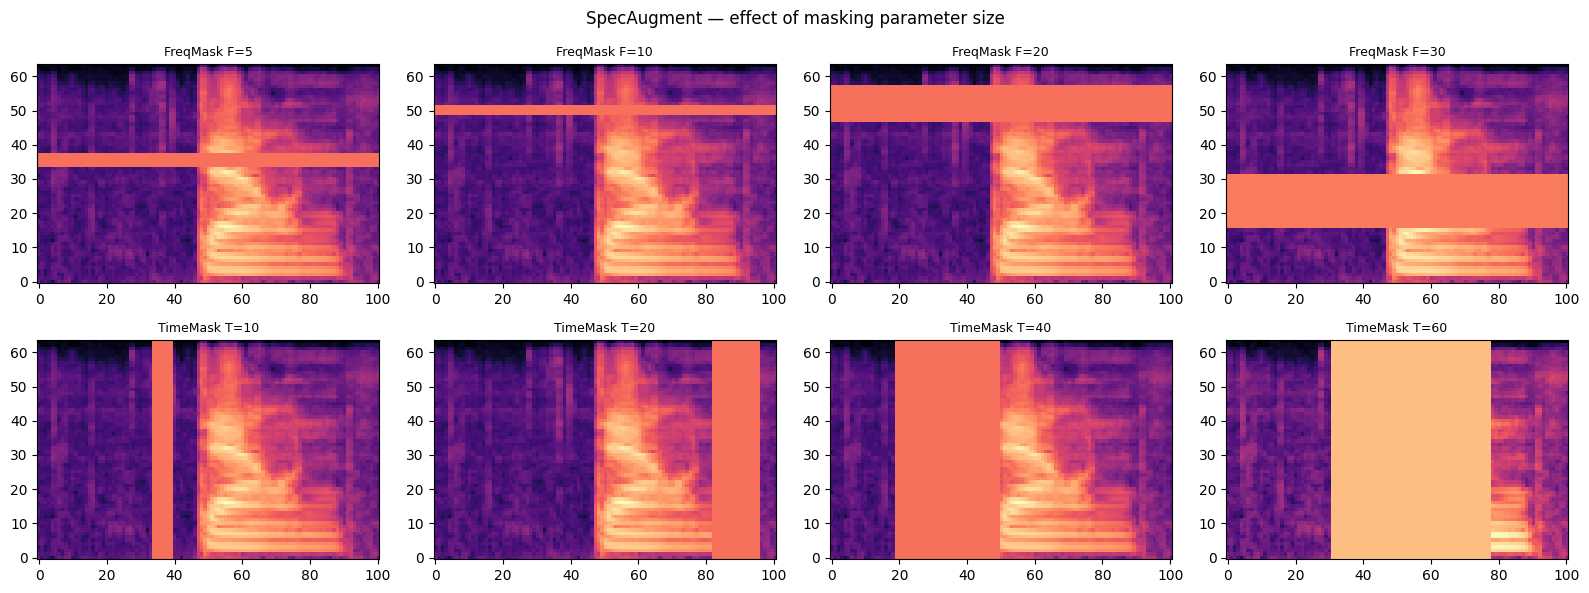

In [19]:
# Show effect of different masking strengths
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

freq_params = [5, 10, 20, 30]
for i, fp in enumerate(freq_params):
    masked = T.FrequencyMasking(freq_mask_param=fp)(mel_original.clone())
    axes[0, i].imshow(masked.squeeze().numpy(), aspect='auto',
                       origin='lower', cmap='magma')
    axes[0, i].set_title(f'FreqMask F={fp}', fontsize=9)

time_params = [10, 20, 40, 60]
for i, tp in enumerate(time_params):
    masked = T.TimeMasking(time_mask_param=tp)(mel_original.clone())
    axes[1, i].imshow(masked.squeeze().numpy(), aspect='auto',
                       origin='lower', cmap='magma')
    axes[1, i].set_title(f'TimeMask T={tp}', fontsize=9)

plt.suptitle('SpecAugment — effect of masking parameter size', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Feature Extraction — Mel Spectrogram & MFCC

For the classifier, we convert waveforms to 2D feature maps.
A CNN then treats these like images.

**Mel Spectrogram**: energy in each mel-frequency band over time
**MFCC**: cosine transform of the log mel spectrogram — compact representation


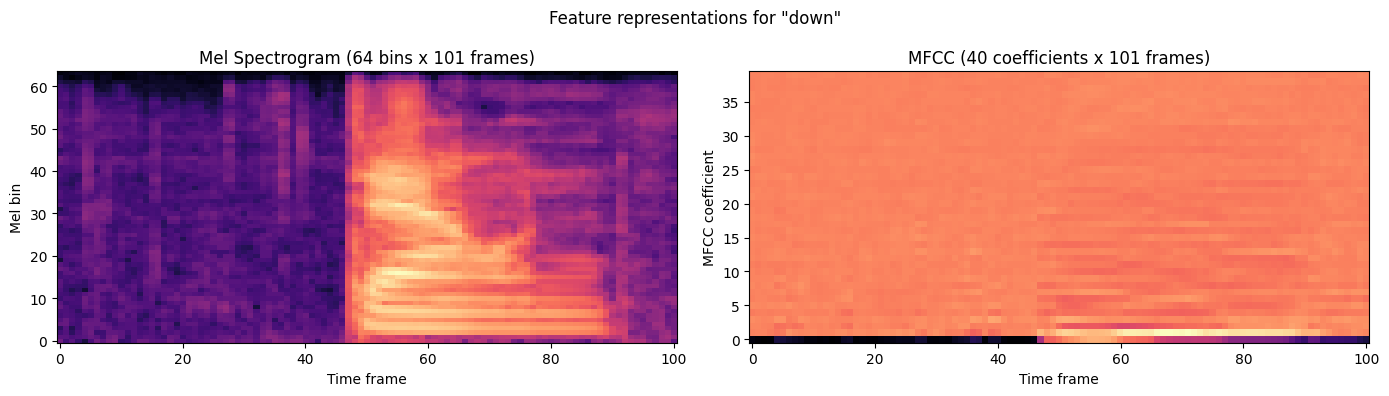

Mel spectrogram shape: (64, 101)   (used as input to CNN)
MFCC shape           : (40, 101)


In [20]:
# Feature extraction transforms (applied at dataset level)
N_MELS    = 64
N_FFT     = 512
HOP_LEN   = 160   # 10ms at 16kHz
N_MFCC    = 40

mel_transform = nn.Sequential(
    T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=N_MELS,
                      n_fft=N_FFT, hop_length=HOP_LEN),
    T.AmplitudeToDB()
)

mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={'n_fft': N_FFT, 'hop_length': HOP_LEN, 'n_mels': N_MELS}
)

# Compute and visualise both features for our sample
wav_t    = torch.tensor(SAMPLE_WAV).unsqueeze(0)
mel_feat = mel_transform(wav_t).squeeze().numpy()
mfcc_feat = mfcc_transform(wav_t).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mel_feat,  aspect='auto', origin='lower', cmap='magma')
axes[0].set_title(f'Mel Spectrogram ({N_MELS} bins x {mel_feat.shape[1]} frames)')
axes[0].set_xlabel('Time frame')
axes[0].set_ylabel('Mel bin')

axes[1].imshow(mfcc_feat, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title(f'MFCC ({N_MFCC} coefficients x {mfcc_feat.shape[1]} frames)')
axes[1].set_xlabel('Time frame')
axes[1].set_ylabel('MFCC coefficient')

plt.suptitle(f'Feature representations for "{SAMPLE_LABEL}"', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mel spectrogram shape: {mel_feat.shape}   (used as input to CNN)')
print(f'MFCC shape           : {mfcc_feat.shape}')

## 8. PyTorch Dataset with Augmentation


In [22]:
class SpeechDataset(Dataset):
    """
    PyTorch Dataset for speech keyword classification.

    Pipeline:
    1. Raw waveform (float32, 16000 samples)
    2. If training: apply audiomentations augmentation
    3. If training: convert to mel spectrogram + apply SpecAugment
    4. If eval: convert to mel spectrogram only
    5. Normalize spectrogram to zero mean, unit std
    6. Output: (1, n_mels, time_frames) tensor
    """
    def __init__(self, wavs, labels, augment=False):
        self.wavs    = wavs
        self.labels  = labels
        self.augment = augment

        # Waveform augmentation (time domain)
        self.wav_aug = AM.Compose([
            AM.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.4),
            AM.TimeStretch(min_rate=0.85, max_rate=1.15, p=0.3),
            AM.PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
            AM.Shift(min_shift=-0.15, max_shift=0.15, p=0.4),
            AM.Gain(p=0.4),
            AM.PolarityInversion(p=0.2),
        ])

        # Spectrogram augmentation (frequency domain)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=10)
        self.time_mask = T.TimeMasking(time_mask_param=20)

        # Feature extraction
        self.mel = nn.Sequential(
            T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=N_MELS,
                              n_fft=N_FFT, hop_length=HOP_LEN),
            T.AmplitudeToDB()
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wav   = self.wavs[idx].copy()
        label = int(self.labels[idx])

        if self.augment:
            # Step 1: waveform augmentation
            wav = self.wav_aug(wav, sample_rate=SAMPLE_RATE)

        # Step 2: feature extraction
        wav_t = torch.tensor(wav).unsqueeze(0)  # (1, 16000)
        mel   = self.mel(wav_t)                   # (1, n_mels, time)

        if self.augment:
            # Step 3: SpecAugment
            if random.random() < 0.5:
                mel = self.freq_mask(mel)
            if random.random() < 0.5:
                mel = self.time_mask(mel)

        # Step 4: normalize spectrogram
        mel = (mel - mel.mean()) / (mel.std() + 1e-8)

        return mel, label


BATCH_SIZE = 64

train_ds_base = SpeechDataset(train_wavs, train_labels, augment=False)
train_ds_aug  = SpeechDataset(train_wavs, train_labels, augment=True)
test_ds       = SpeechDataset(test_wavs,  test_labels,  augment=False)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=2, pin_memory=True)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=2, pin_memory=True)
test_loader       = DataLoader(test_ds,        batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2, pin_memory=True)

X_b, y_b = next(iter(train_loader_aug))
print(f'Batch shape: {X_b.shape}  (B, 1, n_mels, time_frames)')
print(f'Labels     : {y_b[:8].numpy()} -> {[LABELS[i] for i in y_b[:8].numpy()]}')

Batch shape: torch.Size([64, 1, 64, 101])  (B, 1, n_mels, time_frames)
Labels     : [6 9 2 0 6 3 5 4] -> ['on', 'go', 'up', 'yes', 'on', 'down', 'right', 'left']


## 9. CNN Speech Classifier


In [23]:
class SpeechCNN(nn.Module):
    """
    2D CNN that treats mel spectrograms as images.
    Input: (B, 1, n_mels, time_frames)
    Output: (B, n_classes) logits

    Architecture:
    - Three convolutional blocks with BatchNorm
    - Frequency axis (mel bins): acts like height
    - Time axis (frames): acts like width
    - Global average pooling collapses both spatial dimensions
    """
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


test_model = SpeechCNN(n_classes=10).to(device)
print(f'Output: {test_model(X_b.to(device)).shape}  (expect [64, 10])')
print(f'Params: {sum(p.numel() for p in test_model.parameters()):,}')

Output: torch.Size([64, 10])  (expect [64, 10])
Params: 148,394


## 10. A/B Test: No Augmentation vs Full Pipeline


In [24]:
def train_speech_model(train_loader, label='', epochs=25):
    torch.manual_seed(42)
    model     = SpeechCNN(n_classes=len(LABELS)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    hist     = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
        train_acc = correct / total

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | '
                  f'train={train_acc:.4f} | test={test_acc:.4f}')

    print(f'[{label}] Best test accuracy: {best_acc:.4f}\n')
    return hist, best_acc


print('Training WITHOUT augmentation...')
hist_base, acc_base = train_speech_model(
    train_loader_base, label='No aug', epochs=25
)

print('Training WITH audiomentations + SpecAugment...')
hist_aug, acc_aug = train_speech_model(
    train_loader_aug, label='Augmented', epochs=25
)

Training WITHOUT augmentation...
[No aug] Epoch  5 | train=0.7386 | test=0.8520
[No aug] Epoch 10 | train=0.8700 | test=0.9283
[No aug] Epoch 15 | train=0.9009 | test=0.9411
[No aug] Epoch 20 | train=0.9215 | test=0.9553
[No aug] Epoch 25 | train=0.9254 | test=0.9539
[No aug] Best test accuracy: 0.9553

Training WITH audiomentations + SpecAugment...
[Augmented] Epoch  5 | train=0.5813 | test=0.7332
[Augmented] Epoch 10 | train=0.7559 | test=0.8876
[Augmented] Epoch 15 | train=0.8117 | test=0.9303
[Augmented] Epoch 20 | train=0.8360 | test=0.9423
[Augmented] Epoch 25 | train=0.8437 | test=0.9453
[Augmented] Best test accuracy: 0.9465



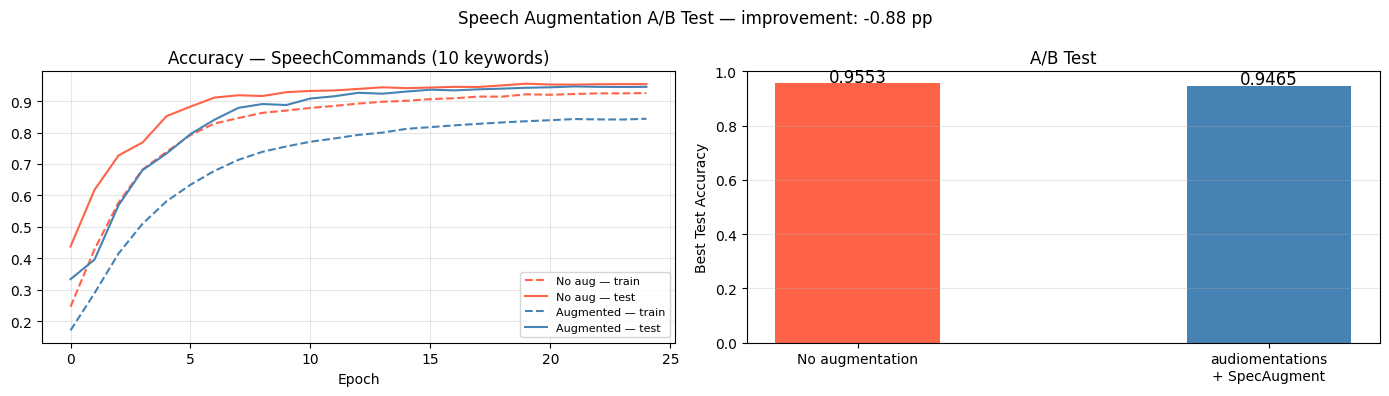

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_acc'], '--', color='tomato',    label='No aug — train')
axes[0].plot(hist_base['test_acc'],        color='tomato',    label='No aug — test')
axes[0].plot(hist_aug['train_acc'],  '--', color='steelblue', label='Augmented — train')
axes[0].plot(hist_aug['test_acc'],         color='steelblue', label='Augmented — test')
axes[0].set_title('Accuracy — SpeechCommands (10 keywords)')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(
    ['No augmentation', 'audiomentations\n+ SpecAugment'],
    [acc_base, acc_aug],
    color=['tomato', 'steelblue'], width=0.4
)
for bar, acc in zip(bars, [acc_base, acc_aug]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{acc:.4f}', ha='center', fontsize=12
    )
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Best Test Accuracy')
axes[1].set_title('A/B Test')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Speech Augmentation A/B Test — '
    f'improvement: {(acc_aug - acc_base)*100:.2f} pp',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## Summary

### Augmentation Techniques Reference

| Technique | Domain | What it simulates |
|---|---|---|
| Gain | Waveform | Different microphone sensitivity / distance |
| Polarity inversion | Waveform | Phase invariance |
| Time shift | Waveform | Keyword at different position in clip |
| Time stretch | Waveform | Speaking speed variation |
| Pitch shift | Waveform | Different speaker vocal tract length |
| White noise | Waveform | Background noise, sensor noise |
| Frequency masking | Spectrogram | Missing frequency bands |
| Time masking | Spectrogram | Temporary occlusion, packet loss |

### Recommended Pipeline
```python
# Step 1: waveform augmentation
AM.Compose([
    AM.AddGaussianNoise(p=0.4),
    AM.TimeStretch(p=0.3),
    AM.PitchShift(p=0.3),
    AM.Shift(p=0.4),
    AM.Gain(p=0.4),
])

# Step 2: spectrogram extraction
mel = MelSpectrogram(...) -> AmplitudeToDB()

# Step 3: SpecAugment
FrequencyMasking(freq_mask_param=10)
TimeMasking(time_mask_param=20)

# Step 4: normalize
mel = (mel - mel.mean()) / (mel.std() + 1e-8)
```

**Next: Notebook 15** — Document Image Augmentation with AugLy
